# Обучение модели ResNet18 для классификации AI vs Human Generated Images

В ноутбуке выполнены:

- обучение модели на `Train_1`;
- проверка качества на `Test_1`;
- логирование `loss`, `accuracy`, `f1_macro` в TensorBoard;
- сохранение модели;
- загрузка модели в локальный S3/MinIO;
- дообучение модели на `Train_2`;
- проверка качества на `Test_2`;
- сравнение двух версий модели.

In [1]:
import os
import json
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from torchvision import transforms
from torchvision.models import resnet18

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [3]:
DATA_DIR = Path("ai-vs-human-generated-dataset-hw")

TRAIN_1 = DATA_DIR / "Train_1"
TEST_1 = DATA_DIR / "Test_1"
TRAIN_2 = DATA_DIR / "Train_2"
TEST_2 = DATA_DIR / "Test_2"

MODEL_DIR = Path("models")
RUNS_DIR = Path("runs")
METRICS_DIR = Path("metrics")

MODEL_DIR.mkdir(exist_ok=True)
RUNS_DIR.mkdir(exist_ok=True)
METRICS_DIR.mkdir(exist_ok=True)

print("DATA_DIR exists:", DATA_DIR.exists())
print("Train_1:", TRAIN_1.exists())
print("Test_1:", TEST_1.exists())
print("Train_2:", TRAIN_2.exists())
print("Test_2:", TEST_2.exists())

DATA_DIR exists: True
Train_1: True
Test_1: True
Train_2: True
Test_2: True


## Dataset

In [4]:
class ImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.csv_file = Path(csv_file)
        self.root_dir = Path(root_dir)
        self.transform = transform

        if not self.csv_file.exists():
            raise FileNotFoundError(f"CSV file not found: {self.csv_file}")

        self.data = pd.read_csv(self.csv_file)

        if "file_name" not in self.data.columns:
            raise ValueError(f"Column 'file_name' not found. Columns: {list(self.data.columns)}")

        if "label" not in self.data.columns:
            raise ValueError(f"Column 'label' not found. Columns: {list(self.data.columns)}")

        if not np.issubdtype(self.data["label"].dtype, np.number):
            labels = sorted(self.data["label"].unique())
            self.label_to_id = {label: idx for idx, label in enumerate(labels)}
            self.data["label"] = self.data["label"].map(self.label_to_id)
        else:
            self.label_to_id = None
            self.data["label"] = self.data["label"].astype(int)

    def __len__(self):
        return len(self.data)

    def _find_image_path(self, file_name):
        file_name = str(file_name)
        base_name = Path(file_name).name

        variants = [
            self.root_dir / file_name,
            self.root_dir / file_name.replace("train_data/", "test_data/"),
            self.root_dir / file_name.replace("test_data/", "train_data/"),
            self.root_dir / "train_data" / base_name,
            self.root_dir / "test_data" / base_name,
            self.root_dir / base_name,
        ]

        for path in variants:
            if path.exists():
                return path

        raise FileNotFoundError(
            "Image not found. Tried:\n" + "\n".join(str(p) for p in variants)
        )

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = self._find_image_path(row["file_name"])

        image = Image.open(img_path).convert("RGB")
        label = int(row["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [5]:
def get_csv_path(split_dir):
    split_dir = Path(split_dir)
    candidates = [
        split_dir / "train.csv",
        split_dir / "test.csv",
        split_dir / "labels.csv",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    csv_files = list(split_dir.glob("*.csv"))
    if len(csv_files) == 1:
        return csv_files[0]

    raise FileNotFoundError(f"Could not find csv file in {split_dir}")


def make_loaders(train_dir, test_dir, batch_size=32, num_workers=0):
    train_csv = get_csv_path(train_dir)
    test_csv = get_csv_path(test_dir)

    train_dataset = ImageDataset(
        csv_file=train_csv,
        root_dir=train_dir,
        transform=train_transform,
    )

    test_dataset = ImageDataset(
        csv_file=test_csv,
        root_dir=test_dir,
        transform=test_transform,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    return train_loader, test_loader


train_loader_1, test_loader_1 = make_loaders(TRAIN_1, TEST_1, batch_size=32, num_workers=0)

print("Train_1 size:", len(train_loader_1.dataset))
print("Test_1 size:", len(test_loader_1.dataset))

images, labels = next(iter(train_loader_1))
print("Batch images:", images.shape)
print("Batch labels:", labels.shape, labels[:10])

Train_1 size: 9993
Test_1 size: 3997
Batch images: torch.Size([32, 3, 224, 224])
Batch labels: torch.Size([32]) tensor([1, 0, 1, 1, 0, 1, 1, 0, 0, 0])


## Модель

In [6]:
def create_model(num_classes=2):
    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


num_classes = int(pd.read_csv(get_csv_path(TRAIN_1))["label"].nunique())
print("num_classes:", num_classes)

model = create_model(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

num_classes: 2


## Функции обучения и оценки

In [7]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
    }


def train_epoch(model, dataloader, criterion, optimizer, device, desc="Train"):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc=desc):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = float(avg_loss)

    return metrics


@torch.no_grad()
def validate(model, dataloader, criterion, device, desc="Valid"):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc=desc):
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = float(avg_loss)

    return metrics

## Обучение первой модели на Train_1 и Test_1

In [8]:
base_epochs = 2

writer = SummaryWriter(RUNS_DIR / "base_resnet18")

writer.add_text("experiment", "Base ResNet18 on Train_1/Test_1")
writer.add_scalar("params/lr", 1e-4, 0)
writer.add_scalar("params/batch_size", 32, 0)
writer.add_scalar("params/epochs", base_epochs, 0)

best_f1 = -1.0
best_model_path = MODEL_DIR / "resnet18_base.pt"

history_base = []

for epoch in range(1, base_epochs + 1):
    print(f"\nEpoch {epoch}/{base_epochs}")

    train_metrics = train_epoch(
        model=model,
        dataloader=train_loader_1,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        desc=f"Train_1 epoch {epoch}",
    )

    test_metrics = validate(
        model=model,
        dataloader=test_loader_1,
        criterion=criterion,
        device=device,
        desc=f"Test_1 epoch {epoch}",
    )

    scheduler.step()

    print("Train:", train_metrics)
    print("Test:", test_metrics)

    writer.add_scalar("Loss/train", train_metrics["loss"], epoch)
    writer.add_scalar("Loss/test", test_metrics["loss"], epoch)

    writer.add_scalar("Accuracy/train", train_metrics["accuracy"], epoch)
    writer.add_scalar("Accuracy/test", test_metrics["accuracy"], epoch)

    writer.add_scalar("F1_macro/train", train_metrics["f1_macro"], epoch)
    writer.add_scalar("F1_macro/test", test_metrics["f1_macro"], epoch)

    writer.add_scalar("Precision_macro/test", test_metrics["precision_macro"], epoch)
    writer.add_scalar("Recall_macro/test", test_metrics["recall_macro"], epoch)

    history_base.append({
        "epoch": epoch,
        "train": train_metrics,
        "test": test_metrics,
    })

    if test_metrics["f1_macro"] > best_f1:
        best_f1 = test_metrics["f1_macro"]
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "num_classes": num_classes,
                "epoch": epoch,
                "metrics": test_metrics,
            },
            best_model_path,
        )
        print("Saved best model:", best_model_path)

writer.close()

with open(METRICS_DIR / "base_metrics.json", "w") as f:
    json.dump(history_base, f, indent=2)

print("Best base F1:", best_f1)


Epoch 1/2


Train_1 epoch 1:   0%|          | 0/313 [00:00<?, ?it/s]

Test_1 epoch 1:   0%|          | 0/125 [00:00<?, ?it/s]

Train: {'accuracy': 0.8785149604723307, 'f1_macro': 0.8785077471014716, 'precision_macro': 0.8786147927944301, 'recall_macro': 0.8785190358055592, 'loss': 0.2916133850291006}
Test: {'accuracy': 0.8466349762321741, 'f1_macro': 0.844137073263421, 'precision_macro': 0.8707997472847837, 'recall_macro': 0.8467946637903493, 'loss': 0.330118942907938}
Saved best model: models/resnet18_base.pt

Epoch 2/2


Train_1 epoch 2:   0%|          | 0/313 [00:00<?, ?it/s]

Test_1 epoch 2:   0%|          | 0/125 [00:00<?, ?it/s]

Train: {'accuracy': 0.9103372360652456, 'f1_macro': 0.9103369765759501, 'precision_macro': 0.9103444625180135, 'recall_macro': 0.9103383151600284, 'loss': 0.23096118851441896}
Test: {'accuracy': 0.8901676257192894, 'f1_macro': 0.8898518808254479, 'precision_macro': 0.8945199998987154, 'recall_macro': 0.8901020431667933, 'loss': 0.27276381554978174}
Saved best model: models/resnet18_base.pt
Best base F1: 0.8898518808254479


## Загрузка модели в S3/MinIO
```bash
docker compose up
```

In [15]:
def upload_to_minio(
    file_path,
    bucket_name="models",
    object_name=None,
    endpoint_url="http://localhost:9000",
    aws_access_key_id="minioadmin",
    aws_secret_access_key="minioadmin",
):
    try:
        import boto3
        from botocore.exceptions import ClientError, EndpointConnectionError
    except ImportError:
        print("boto3 is not installed. Run: pip install boto3")
        return False

    file_path = Path(file_path)
    object_name = object_name or file_path.name

    s3 = boto3.client(
        "s3",
        endpoint_url=endpoint_url,
        aws_access_key_id=aws_access_key_id,
        aws_secret_access_key=aws_secret_access_key,
    )

    try:
        buckets = [b["Name"] for b in s3.list_buckets().get("Buckets", [])]
        if bucket_name not in buckets:
            s3.create_bucket(Bucket=bucket_name)

        s3.upload_file(str(file_path), bucket_name, object_name)
        print(f"Uploaded {file_path} to s3://{bucket_name}/{object_name}")
        return True

    except Exception as e:
        print("MinIO upload skipped:", repr(e))
        return False

In [14]:
upload_to_minio(best_model_path, object_name="resnet18_base.pt")

Uploaded models/resnet18_base.pt to s3://models/resnet18_base.pt


True

## Дообучение на Train_2 и Test_2

In [16]:
if TRAIN_2.exists() and TEST_2.exists():
    train_loader_2, test_loader_2 = make_loaders(TRAIN_2, TEST_2, batch_size=32, num_workers=0)

    print("Train_2 size:", len(train_loader_2.dataset))
    print("Test_2 size:", len(test_loader_2.dataset))

    finetune_model = create_model(num_classes=num_classes).to(device)

    checkpoint = torch.load(best_model_path, map_location=device)
    finetune_model.load_state_dict(checkpoint["model_state_dict"])

    finetune_criterion = nn.CrossEntropyLoss()
    finetune_optimizer = torch.optim.AdamW(finetune_model.parameters(), lr=5e-5, weight_decay=1e-4)
    finetune_scheduler = torch.optim.lr_scheduler.StepLR(finetune_optimizer, step_size=2, gamma=0.5)

    finetune_epochs = 2

    writer = SummaryWriter(RUNS_DIR / "finetune_resnet18")

    best_f1_2 = -1.0
    finetuned_model_path = MODEL_DIR / "resnet18_finetuned.pt"

    history_finetune = []

    for epoch in range(1, finetune_epochs + 1):
        print(f"\nFinetune epoch {epoch}/{finetune_epochs}")

        train_metrics = train_epoch(
            model=finetune_model,
            dataloader=train_loader_2,
            criterion=finetune_criterion,
            optimizer=finetune_optimizer,
            device=device,
            desc=f"Train_2 epoch {epoch}",
        )

        test_metrics = validate(
            model=finetune_model,
            dataloader=test_loader_2,
            criterion=finetune_criterion,
            device=device,
            desc=f"Test_2 epoch {epoch}",
        )

        finetune_scheduler.step()

        print("Train_2:", train_metrics)
        print("Test_2:", test_metrics)

        writer.add_scalar("Loss/train", train_metrics["loss"], epoch)
        writer.add_scalar("Loss/test", test_metrics["loss"], epoch)

        writer.add_scalar("Accuracy/train", train_metrics["accuracy"], epoch)
        writer.add_scalar("Accuracy/test", test_metrics["accuracy"], epoch)

        writer.add_scalar("F1_macro/train", train_metrics["f1_macro"], epoch)
        writer.add_scalar("F1_macro/test", test_metrics["f1_macro"], epoch)

        history_finetune.append({
            "epoch": epoch,
            "train": train_metrics,
            "test": test_metrics,
        })

        if test_metrics["f1_macro"] > best_f1_2:
            best_f1_2 = test_metrics["f1_macro"]
            torch.save(
                {
                    "model_state_dict": finetune_model.state_dict(),
                    "num_classes": num_classes,
                    "epoch": epoch,
                    "metrics": test_metrics,
                },
                finetuned_model_path,
            )
            print("Saved best finetuned model:", finetuned_model_path)

    writer.close()

    with open(METRICS_DIR / "finetune_metrics.json", "w") as f:
        json.dump(history_finetune, f, indent=2)

    upload_to_minio(finetuned_model_path, object_name="resnet18_finetuned.pt")

else:
    print("Train_2/Test_2 folders not found. Download them before running finetuning.")

Train_2 size: 3997
Test_2 size: 2000

Finetune epoch 1/2


Train_2 epoch 1:   0%|          | 0/125 [00:00<?, ?it/s]

Test_2 epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]

Train_2: {'accuracy': 0.924193144858644, 'f1_macro': 0.9241698870128555, 'precision_macro': 0.924146696351875, 'recall_macro': 0.9241987516656147, 'loss': 0.19991271302182287}
Test_2: {'accuracy': 0.9135, 'f1_macro': 0.9133846066421991, 'precision_macro': 0.9162273270578198, 'recall_macro': 0.9137053426335658, 'loss': 0.22870810711383818}
Saved best finetuned model: models/resnet18_finetuned.pt

Finetune epoch 2/2


Train_2 epoch 2:   0%|          | 0/125 [00:00<?, ?it/s]

Test_2 epoch 2:   0%|          | 0/63 [00:00<?, ?it/s]

Train_2: {'accuracy': 0.9379534650988242, 'f1_macro': 0.9379226867988203, 'precision_macro': 0.9379897340616898, 'recall_macro': 0.937872571709096, 'loss': 0.16471514655503147}
Test_2: {'accuracy': 0.906, 'f1_macro': 0.905537131946538, 'precision_macro': 0.9150897622513343, 'recall_macro': 0.9063726593164829, 'loss': 0.25330568018555644}
Uploaded models/resnet18_finetuned.pt to s3://models/resnet18_finetuned.pt


## Сравнение моделей

In [17]:
base_metrics_path = METRICS_DIR / "base_metrics.json"
finetune_metrics_path = METRICS_DIR / "finetune_metrics.json"

comparison = {}

if base_metrics_path.exists():
    with open(base_metrics_path) as f:
        base_history = json.load(f)

    base_best = max(base_history, key=lambda x: x["test"]["f1_macro"])
    comparison["base"] = {
        "best_epoch": base_best["epoch"],
        "test_accuracy": base_best["test"]["accuracy"],
        "test_f1_macro": base_best["test"]["f1_macro"],
        "test_precision_macro": base_best["test"]["precision_macro"],
        "test_recall_macro": base_best["test"]["recall_macro"],
    }

if finetune_metrics_path.exists():
    with open(finetune_metrics_path) as f:
        finetune_history = json.load(f)

    finetune_best = max(finetune_history, key=lambda x: x["test"]["f1_macro"])
    comparison["finetuned"] = {
        "best_epoch": finetune_best["epoch"],
        "test_accuracy": finetune_best["test"]["accuracy"],
        "test_f1_macro": finetune_best["test"]["f1_macro"],
        "test_precision_macro": finetune_best["test"]["precision_macro"],
        "test_recall_macro": finetune_best["test"]["recall_macro"],
    }

with open(METRICS_DIR / "comparison.json", "w") as f:
    json.dump(comparison, f, indent=2)

comparison

{'base': {'best_epoch': 2,
  'test_accuracy': 0.8901676257192894,
  'test_f1_macro': 0.8898518808254479,
  'test_precision_macro': 0.8945199998987154,
  'test_recall_macro': 0.8901020431667933},
 'finetuned': {'best_epoch': 1,
  'test_accuracy': 0.9135,
  'test_f1_macro': 0.9133846066421991,
  'test_precision_macro': 0.9162273270578198,
  'test_recall_macro': 0.9137053426335658}}

## TensorBoard

```bash
tensorboard --logdir runs
```

```text
http://localhost:6006
```

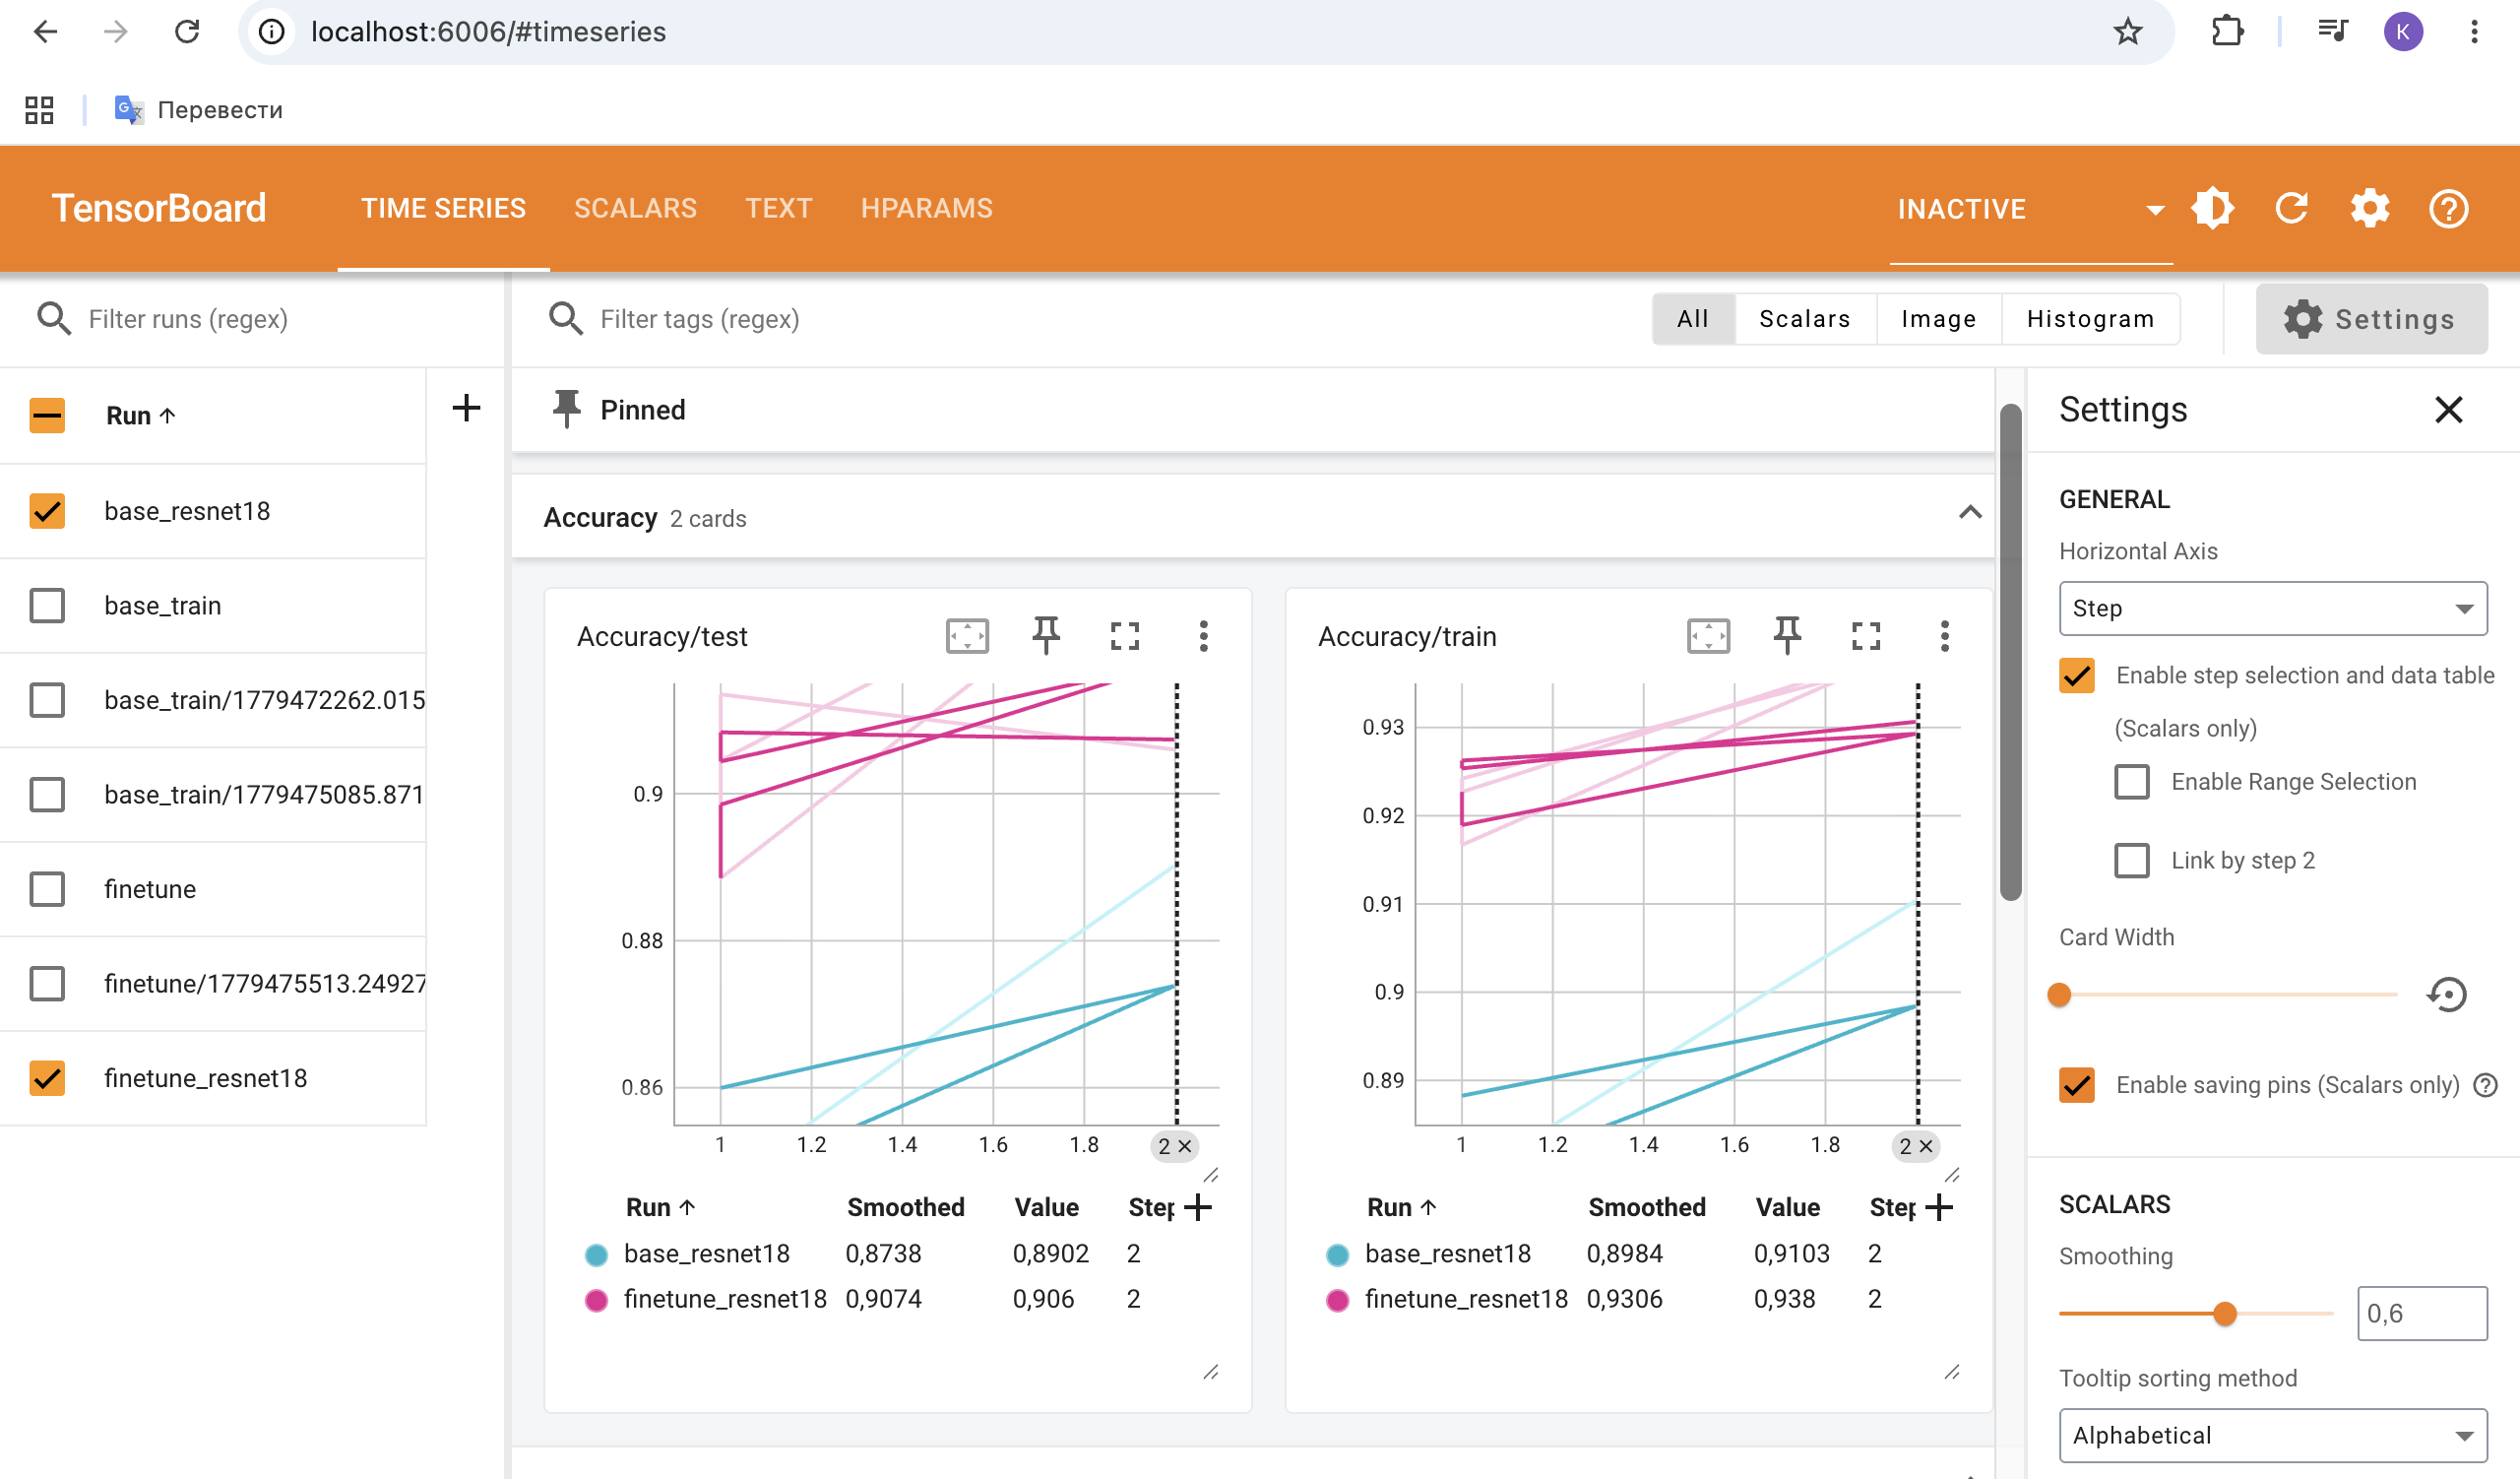

## DVC pipeline

```bash
dvc init
dvc repro
dvc dag
```

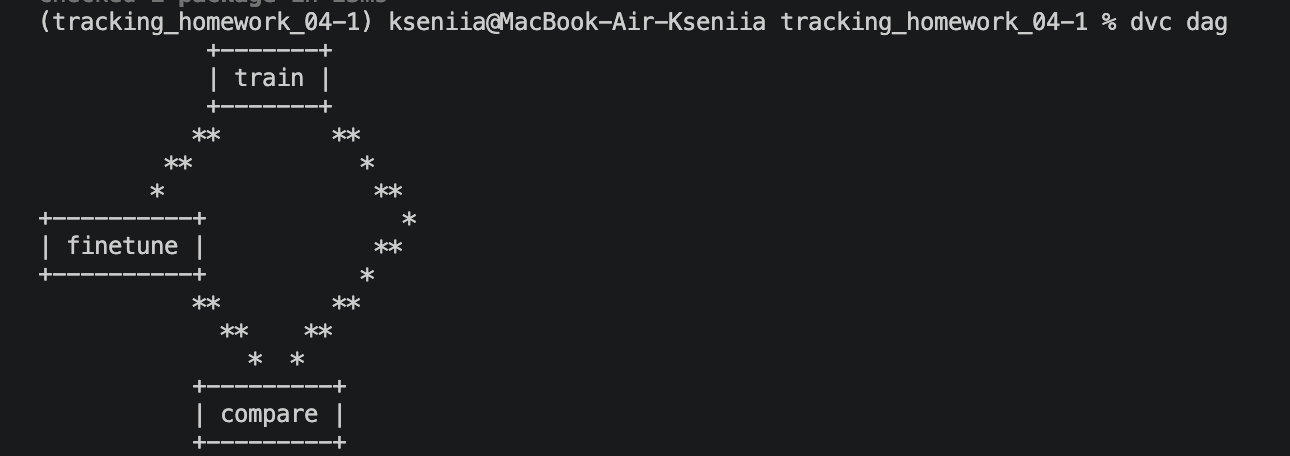